In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea

%matplotlib inline
import os

from google.colab import drive

In [49]:
drive.mount('/content/drive')
pd.pandas.set_option('display.max_columns', None)
pd.pandas.set_option('display.max_rows', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading the dataset

In [50]:
dirty_cafe_dataset = pd.read_csv('/content/drive/MyDrive/AI_ML_Foundation/000_The Real Laboratory/The Lead Architects Challenges/EDA + FE + FS/dirty_cafe_sales.csv')
dataset = dirty_cafe_dataset.copy()

In [51]:
# Seeing the dataset

display(dataset.head())
display(dataset.isna().sum())

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [52]:
#1. Let us group features that have missing values

features_with_nan = [feature for feature in dataset.columns if dataset[feature].isnull().sum() > 1]

print(features_with_nan)

#2. See the %tage of missing values in each columns
for feature in features_with_nan:
  print(feature, np.round(dataset[feature].isnull().mean(), 4), "% Missing Values")

['Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']
Item 0.0333 % Missing Values
Quantity 0.0138 % Missing Values
Price Per Unit 0.0179 % Missing Values
Total Spent 0.0173 % Missing Values
Payment Method 0.2579 % Missing Values
Location 0.3265 % Missing Values
Transaction Date 0.0159 % Missing Values


In [53]:
from pandas.core.arrays import categorical
#3. Some of our potential numerical features have 'ERROR' or 'UNKNOWN' string values. whcih we find hard to convert into numeric values

# We are converting potentially numerical values to Numerical and Coercing the NaN values.

dataset['Quantity'] = pd.to_numeric(dataset['Quantity'], errors='coerce')
dataset['Price Per Unit'] = pd.to_numeric(dataset['Price Per Unit'] ,
                                          errors='coerce')
dataset['Total Spent'] = pd.to_numeric(dataset['Total Spent'], errors='coerce')\



#4. Now we have coerced the errors and unknowns, now we will identify the numerical and categorical values
numerical_features = [feature for feature in dataset.columns if pd.api.types.is_numeric_dtype(dataset[feature])]

categorical_features = [feature for feature in dataset.columns if pd.api.types.is_object_dtype(dataset[feature])]

print("Numerical Features:", numerical_features)
print("Categorical Features: ", categorical_features)

Numerical Features: ['Quantity', 'Price Per Unit', 'Total Spent']
Categorical Features:  ['Transaction ID', 'Item', 'Payment Method', 'Location', 'Transaction Date']


In [54]:
#5. From numerical features: let us classify i) Discrete features and ii) Numerical Features

discrete_features = [feature for feature in numerical_features if dataset[feature].nunique() < 25 and pd.api.types.is_integer_dtype(dataset[feature].dropna()) and feature not in ['Transaction ID']]

continuous_features = [feature for feature in numerical_features if feature not in discrete_features and feature not in ['Trnsaction ID']]

print(f"Continuous: {continuous_features}\n Discrete: {discrete_features}")

Continuous: ['Quantity', 'Price Per Unit', 'Total Spent']
 Discrete: []


We don't have discrete features we only have continous features in numerical features.|

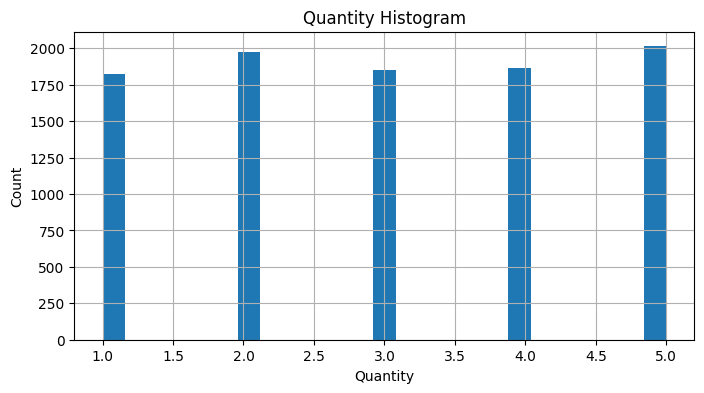

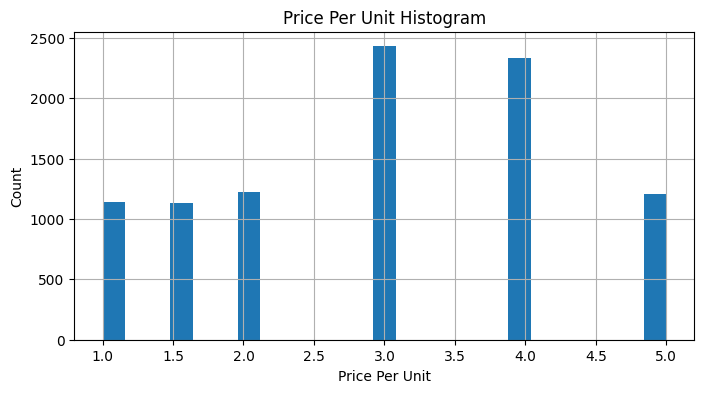

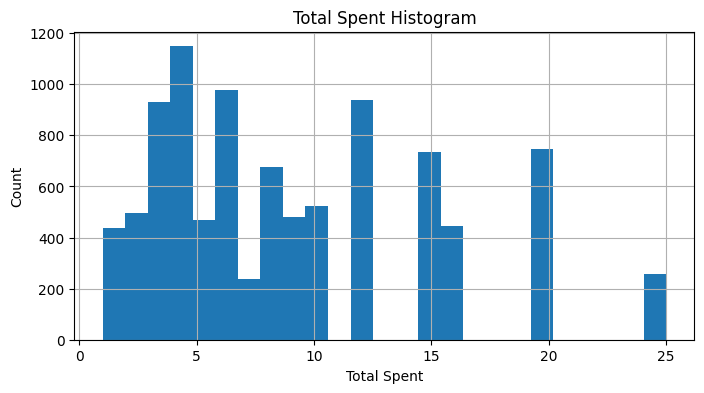

In [55]:
#6. Checking histograms of continuous features before checking for outliers.
for feature in continuous_features:
  data = dataset.copy()
  plt.figure(figsize=(8,4))
  data[feature].hist(bins=25) # hist function on column directly applied

  plt.xlabel(feature)
  plt.ylabel("Count")
  plt.title(f"{feature} Histogram")
  plt.show()

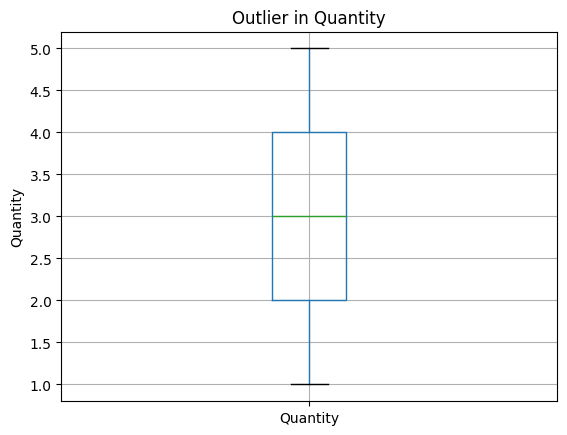

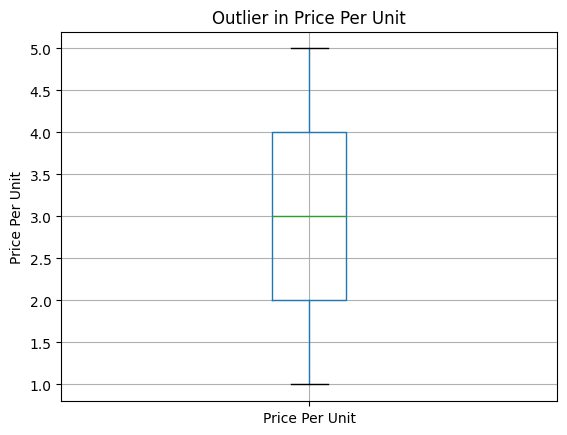

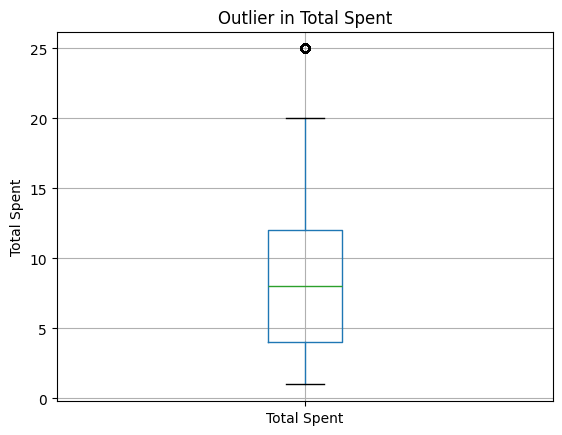

In [56]:
#6. checking errors
# data is nto skewed to any side so no log transformation.

# Plotting box-plots
data = dataset.copy()
for feature in continuous_features:
  if 0 in data[feature].unique():
    pass
  else:
    data.boxplot(column = feature)
    plt.ylabel(feature)
    plt.title(f"Outlier in {feature}")
    plt.show()

In [57]:
## Reviewing the current state of dataset
print(f"Current dataset info: {dataset.info()}")

print("Missing Values after initial type conversion:\n", dataset[numerical_features].isnull().sum())

print("First 5 rows of the dataset", dataset.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9667 non-null   object 
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    7421 non-null   object 
 6   Location          6735 non-null   object 
 7   Transaction Date  9841 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB
Current dataset info: None
Missing Values after initial type conversion:
 Quantity          479
Price Per Unit    533
Total Spent       502
dtype: int64
First 5 rows of the dataset   Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
0    TXN_1961373  Coffee       2.0             2.0          4.0   
1    TXN_4977031    Cake       4.0             3.0    

In [58]:
#7. Let us now impute the missing Item Values based on 'Price Per Unit'
# Here we create a mapping: from existing 'PPU --> Item' t fill in missing 'Item' entries.

## 7.1: Create a dict to map known PPU to Item. If a price has multiple value: we pick frequent one : (Mode). This map helps us fill in missing 'Item' values.

price_to_item_mapping = dataset.dropna(subset= ['Price Per Unit', 'Item']) \
                                      .groupby('Price Per Unit')['Item'] \
                                      .agg(lambda x: x.mode()[0]
                                           if not x.mode().empty else np.nan).to_dict()

## 7.2: Fill missing 'Item' values:
# We will only try to fill "Item" where it is currently NaN and where we have a known 'Price Per Unit' that exists in our mapping. here we are using .map() function to look up for item for each price

dataset['Item'] = dataset['Item'].fillna(dataset['Price Per Unit'].map(price_to_item_mapping))

print("Missing 'Item' Column Values After Imputation")
print(dataset['Item'].isnull().sum())

Missing 'Item' Column Values After Imputation
23


In [59]:
# 8. Let us impute the Missing Financial Values:
# Quantity Price Per Unit and Total Spent as Total Spent = Quantity * Price Per Unit. Iterate through the columns, filling in missing values where two/ three values are present.

print("Missing Values BEFORE imputation for financial columns: ")
print(dataset[['Quantity', 'Price Per Unit', 'Total Spent']].isnull().sum())

# Logic: We will run this loop a few times: This is because filling one missing value might provide enough information to fill another missing value in the next iteration.

for _ in range(3):

  # 1: Fill Total Spent if Quantity And PPU are known: TS = Q * PPU
  condition_fill_total = dataset['Total Spent'].isnull() & \
                          dataset['Quantity'].notnull() & \
                          dataset["Price Per Unit"].notnull()

  dataset.loc[condition_fill_total, 'Total Spent'] = dataset['Quantity'] * dataset['Price Per Unit']

  # 2: Fill Quantity if Total Spent and PPU are known: Q = TS/PPU
  condition_fill_quantity = dataset['Quantity'].isnull() & \
                          dataset['Total Spent'].notnull() & \
                          dataset["Price Per Unit"].notnull() & \
                          (dataset['Price Per Unit'] != 0)

  dataset.loc[condition_fill_quantity, 'Quantity'] = dataset['Total Spent'] /dataset['Price Per Unit']

  # 3: Fill Price Per Unit if Total Spent and Quantity are known: PPU = TS/Q
  condition_fill_price = dataset['Price Per Unit'].isnull() & \
                          dataset['Total Spent'].notnull() & \
                          dataset["Quantity"].notnull() & \
                          (dataset['Quantity'] != 0)

  dataset.loc[condition_fill_price, 'Price Per Unit'] = \
        dataset['Total Spent'] /dataset['Quantity']


print("\n Missing values AFTER imputation for financial columns: ")
print(dataset[['Quantity', 'Price Per Unit', 'Total Spent']].isnull().sum())

Missing Values BEFORE imputation for financial columns: 
Quantity          479
Price Per Unit    533
Total Spent       502
dtype: int64

 Missing values AFTER imputation for financial columns: 
Quantity          38
Price Per Unit    38
Total Spent       40
dtype: int64


In [60]:
dataset.isnull().sum()

,0
Transaction ID,0
Item,23
Quantity,38
Price Per Unit,38
Total Spent,40
Payment Method,2579
Location,3265
Transaction Date,159


In [61]:
#9. Let us handle the missing values from 'Payment Method' and 'Location' and the last few Item NaN's

# 1. Imputing Payment method: We will impute it with "Unknown Payment Method"
# 2. Impute Location with Unknown Location
# 3. Impute remaining item missing values with Unknown values.

# Get most frequent item:
# 3. Handling remaining item missing value
def get_most_frequent_item(item_series):
  "Returns: MFI from series, Nan if empty"
  if not item_series.mode().empty:
    return item_series.mode()[0]
  return np.nan

## More simple mapping function

price_to_item_mapping =  (dataset.dropna(subset=['Price Per Unit', 'Item'])
                          .groupby('Price Per Unit')['Item']
                          .agg(get_most_frequent_item)
                          .to_dict())

dataset['Item'] = dataset["Item"].fillna(dataset['Price Per Unit'].map(price_to_item_mapping))

print("Missing `Item` values after imputation")
print(dataset['Item'].isnull().sum())

# 9.3 Now we will replace NaN , 'Unknown' and 'Error' string entries by replacing them with 'Unknown Item'


# Fill remaining NaN values with Unknown Item
dataset['Item'] = dataset['Item'].fillna('Unknown Item')

# replace any unknown or Error string in Item with Unknown Item
dataset['Item'] = dataset['Item'].replace(['UNKNOWN', 'ERROR'], 'Unknown Item')

print("Missing value AFTER imputation:")
print(dataset['Item'].isnull().sum())

print("Unique 'item' values containing 'Unknown' after cleaning: ")
print(dataset[dataset['Item'].str.contains('Unknown', na=False)]['Item'].unique())

Missing `Item` values after imputation
2
Missing value AFTER imputation:
0
Unique 'item' values containing 'Unknown' after cleaning: 
['Unknown Item']


In [62]:
# 9.1 and 9.2
# Fill NaN values in 'Payment Method' with 'Unknown Payment Method'
dataset['Payment Method'] = dataset['Payment Method'].fillna('Unknown Payment Method')
# Replace 'UNKNOWN' and 'ERROR' strings in 'Payment Method'
dataset['Payment Method'] = dataset['Payment Method'].replace(['UNKNOWN', 'ERROR'], 'Unknown Payment Method')

# Fill NaN values in 'Location' with 'Unknown Location'
dataset['Location'] = dataset['Location'].fillna('Unknown Location')
# Replace 'UNKNOWN' and 'ERROR' strings in 'Location'
dataset['Location'] = dataset['Location'].replace(['UNKNOWN', 'ERROR'], 'Unknown Location')

print("Missing Values after imputing 'Item' 'Payment Method' and' Location': ")
print(dataset[['Item', 'Payment Method', 'Location']].isnull().sum())

Missing Values after imputing 'Item' 'Payment Method' and' Location': 
Item              0
Payment Method    0
Location          0
dtype: int64


In [63]:
# >> Displaying the dataset after imputation
display(dataset.head(100))

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown Payment Method,Unknown Location,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Unknown Location,2023-03-31
6,TXN_4433211,Unknown Item,3.0,3.0,9.0,Unknown Payment Method,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Unknown Location,2023-10-28
8,TXN_4717867,Juice,5.0,3.0,15.0,Unknown Payment Method,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Unknown Payment Method,In-store,2023-12-31


10. FEATURE ENGINEERING THE TRANSACTION DATE

In [64]:
from pickleshare import errno
#10

# Converting Transaction date to datetime objcts, coercing errors
dataset['Transaction Date'] = pd.to_datetime(dataset['Transaction Date'], errors='coerce')

# We will now extract some new temporal features:
dataset['Year'] = dataset['Transaction Date'].dt.year
dataset['Month'] = dataset['Transaction Date'].dt.month
dataset['Day of Week'] = dataset['Transaction Date'].dt.day_of_week
# here Mon = 0 and Sun = 6
dataset['Day_of_Month'] = dataset['Transaction Date'].dt.day
dataset['IsWeekend'] = (dataset['Transaction Date'].dt.dayofweek >=5).astype(int) # It will be 1 for weekend (Sat or Sun) or 0 for weekday

print("Missing values in 'Transaction Date' after conversion:")
print(dataset['Transaction Date'].isnull().sum())

# Let us print the new dataset.
display(dataset.head())

Missing values in 'Transaction Date' after conversion:
460


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,4.0,8.0,0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023.0,5.0,1.0,16.0,0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023.0,7.0,2.0,19.0,0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown Payment Method,Unknown Location,2023-04-27,2023.0,4.0,3.0,27.0,0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023.0,6.0,6.0,11.0,1


In [65]:
import numpy as np
# Update the categorical features list: now to include new date related categorical features if they are of the type 'object'and numerical feature for year, month etc

# 10.1: Redefine numerical_features to include all numeric columns
numerical_features = [feature for feature in dataset.columns if pd.api.types.is_numeric_dtype(dataset[feature])]

# Redefine categorical_features, excluding numerical columns and the original 'Transaction Date'
categorical_features = [feature for feature in dataset.columns if pd.api.types.is_object_dtype(dataset[feature]) and feature not in ['Transaction Date']]


print("Updated Numerical Features: ", numerical_features)
print("Updated Categorical Features: ", categorical_features)

#Verify datatypes of new columns
print("\nData types of new data features:")
print(dataset[['Year', 'Month', 'Day of Week', 'Day_of_Month', 'IsWeekend']].dtypes)

Updated Numerical Features:  ['Quantity', 'Price Per Unit', 'Total Spent', 'Year', 'Month', 'Day of Week', 'Day_of_Month', 'IsWeekend']
Updated Categorical Features:  ['Transaction ID', 'Item', 'Payment Method', 'Location']

Data types of new data features:
Year            float64
Month           float64
Day of Week     float64
Day_of_Month    float64
IsWeekend         int64
dtype: object


In [66]:
## REVIEW AFTER CLEANING AND FEATURE ENGINEERING

display(dataset.head(10))

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,4.0,8.0,0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023.0,5.0,1.0,16.0,0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023.0,7.0,2.0,19.0,0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown Payment Method,Unknown Location,2023-04-27,2023.0,4.0,3.0,27.0,0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023.0,6.0,6.0,11.0,1
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Unknown Location,2023-03-31,2023.0,3.0,4.0,31.0,0
6,TXN_4433211,Unknown Item,3.0,3.0,9.0,Unknown Payment Method,Takeaway,2023-10-06,2023.0,10.0,4.0,6.0,0
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Unknown Location,2023-10-28,2023.0,10.0,5.0,28.0,1
8,TXN_4717867,Juice,5.0,3.0,15.0,Unknown Payment Method,Takeaway,2023-07-28,2023.0,7.0,4.0,28.0,0
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Unknown Payment Method,In-store,2023-12-31,2023.0,12.0,6.0,31.0,1


In [67]:
# one final check:
print("Total missing values across all columns after cleaning and feature engineering: ")
print(dataset.isnull().sum())

print('\nDataset info dtypes and null counts')
dataset.info()

print("\nFirst 5 rows of the fully processed dataset")
display(dataset.head())


Total missing values across all columns after cleaning and feature engineering: 
Transaction ID        0
Item                  0
Quantity             38
Price Per Unit       38
Total Spent          40
Payment Method        0
Location              0
Transaction Date    460
Year                460
Month               460
Day of Week         460
Day_of_Month        460
IsWeekend             0
dtype: int64

Dataset info dtypes and null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          9962 non-null   float64       
 3   Price Per Unit    9962 non-null   float64       
 4   Total Spent       9960 non-null   float64       
 5   Payment Method    10000 non-null  object        
 6   Location    

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,4.0,8.0,0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023.0,5.0,1.0,16.0,0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023.0,7.0,2.0,19.0,0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown Payment Method,Unknown Location,2023-04-27,2023.0,4.0,3.0,27.0,0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023.0,6.0,6.0,11.0,1


In [68]:
# 11. Handle Remaining financial NaNs wit 0
print("Missing values BEFORE imputing financial columsn with 0:")
print(dataset[['Quantity', 'Price Per Unit', 'Total Spent']].isnull().sum())

dataset['Quantity'] = dataset['Quantity'].fillna(0)
dataset['Price Per Unit'] = dataset['Price Per Unit'].fillna(0)
dataset['Total Spent'] = dataset['Total Spent'].fillna(0)

print("\n Missing values AFTER imputing financial columns with 0:")
print(dataset[['Quantity', 'Price Per Unit', 'Total Spent']].isnull().sum())

Missing values BEFORE imputing financial columsn with 0:
Quantity          38
Price Per Unit    38
Total Spent       40
dtype: int64

 Missing values AFTER imputing financial columns with 0:
Quantity          0
Price Per Unit    0
Total Spent       0
dtype: int64


In [69]:
#12. Let us handle te 'missing' Transaction Date values:
# Created a flag for missing transaction dates:

dataset['Transaction_Date_Missing_Flag'] = dataset['Transaction Date'].isnull().astype(int)

# Find the earliest valid date in the dataset to use as a place holder, This makes the placeholder less arbitrary than a ficed 'YYYY-MM-DD'
earliest_date = dataset['Transaction Date'].min()

# Imput NaT values in 'Transaction Date' with the earliest valid date:
dataset['Transaction Date'] = dataset['Transaction Date'].fillna(earliest_date)

print("Missing values in 'Transaction Date' after imputation: ")
print(dataset['Transaction Date'].isnull().sum())

print("\n Number of rows where the original data was missing: ")
print(dataset['Transaction_Date_Missing_Flag'].sum())

Missing values in 'Transaction Date' after imputation: 
0

 Number of rows where the original data was missing: 
460


In [70]:
# 12.1: Re-derive temporal features from the now complete 'Transaction Date' column
# This ensures consistency and fills any NaNs in these derived features

dataset['Year'] = dataset['Transaction Date'].dt.year.astype(int)
dataset['Month'] = dataset['Transaction Date'].dt.month.astype(int)
dataset['Day of Week'] = dataset['Transaction Date'].dt.dayofweek.astype(int) # Monday=0, Sunday=6
dataset['Day_of_Month'] = dataset['Transaction Date'].dt.day.astype(int)
# Recalculate Is_Weekend to ensure it reflects the imputed dates as well
dataset['IsWeekend'] = (dataset['Transaction Date'].dt.dayofweek >= 5).astype(int)

print("\nMissing values in temporal features after re-derivation:")
print(dataset[['Year', 'Month', 'Day of Week', 'Day_of_Month', 'IsWeekend']].isnull().sum())


Missing values in temporal features after re-derivation:
Year            0
Month           0
Day of Week     0
Day_of_Month    0
IsWeekend       0
dtype: int64


In [71]:
# Review:
print("Total missing values across all columns after final imputation:")
print(dataset.isnull().sum())

print("\nDataset Info (data types and non-null counts):")
dataset.info()

print("\nFirst 5 rows of the fully processed dataset:")
display(dataset.head())

Total missing values across all columns after final imputation:
Transaction ID                   0
Item                             0
Quantity                         0
Price Per Unit                   0
Total Spent                      0
Payment Method                   0
Location                         0
Transaction Date                 0
Year                             0
Month                            0
Day of Week                      0
Day_of_Month                     0
IsWeekend                        0
Transaction_Date_Missing_Flag    0
dtype: int64

Dataset Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Transaction ID                 10000 non-null  object        
 1   Item                           10000 non-null  object        
 2   Quan

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,4,8,0,0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023,5,1,16,0,0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,2,19,0,0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown Payment Method,Unknown Location,2023-04-27,2023,4,3,27,0,0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,6,11,1,0


In [72]:
# Validating:
# 13. Now that we have completed : Data cleaning and Feature Engineering: it is essential to validate our work, We will now check the logical consistency of the imputed values and the correctness of newly derived features

# 13.1: Verifying Imputed financial values.
# Checking for illogical combos where Q and PPU are 0 but TS is not
# Case 1: TS = 0 but Q and PPU ain't

illogical_spent_zero = dataset[(dataset['Total Spent']== 0) & ((dataset['Quantity'] != 0) | (dataset['Price Per Unit'] != 0))]
print(f"Number of illogical cases (TS = 0 but Q/PPU ain't: {len(illogical_spent_zero)}")

illogical_quantity_zero = dataset[(dataset['Quantity'] == 0) & ((dataset['Total Spent'] != 0) | (dataset['Price Per Unit'] != 0))]
print(f"Number of illogical cases (Q = 0 but TS/PPU ain't: {len(illogical_quantity_zero)}")


illogical_ppu_zero = dataset[(dataset['Price Per Unit'] == 0) & ((dataset['Total Spent'] != 0) | (dataset['Quantity'] != 0))]
print(f"Number of illogical cases (PPU = 0 but TS/Q ain't: {len(illogical_quantity_zero)}")


# 13.2: It is expected to have 0 in Q/PPU/TS for originally missing values, as these mean no transaction or no price. We want to ensure no conflicts with product of non-zero values.
# A quick check: filter rows where Q!=0 and PPU != 0, and then check if 'TS' is indeed Q*PPU.

consistency_check = dataset[(dataset['Quantity']!=0) & (dataset['Price Per Unit'] !=0 )]
inconsistent_calculated_total_spent = consistency_check[consistency_check['Total Spent'] != (consistency_check['Quantity'] * consistency_check['Price Per Unit'])]
print(f"Number of inconsistent calculated TS values: (non zero Q and PPU) : {len(inconsistent_calculated_total_spent)}")

# 13.2:
# Display some of the potentially problematic rows if any:
if not illogical_spent_zero.empty: display(illogical_spent_zero.head())
if not illogical_quantity_zero.empty: display(illogical_quantity_zero.head())
if not illogical_ppu_zero.empty: display(illogical_ppu_zero.head())
if not inconsistent_calculated_total_spent.empty: display(inconsistent_calculated_total_spent.head())

Number of illogical cases (TS = 0 but Q/PPU ain't: 40
Number of illogical cases (Q = 0 but TS/PPU ain't: 38
Number of illogical cases (PPU = 0 but TS/Q ain't: 38
Number of inconsistent calculated TS values: (non zero Q and PPU) : 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
65,TXN_4987129,Sandwich,3.0,0.0,0.0,Unknown Payment Method,In-store,2023-10-20,2023,10,4,20,0,0
236,TXN_8562645,Salad,0.0,5.0,0.0,Unknown Payment Method,In-store,2023-05-18,2023,5,3,18,0,0
278,TXN_3229409,Juice,0.0,3.0,0.0,Cash,Takeaway,2023-04-15,2023,4,5,15,1,0
641,TXN_2962976,Juice,0.0,3.0,0.0,Unknown Payment Method,Unknown Location,2023-03-17,2023,3,4,17,0,0
738,TXN_8696094,Sandwich,0.0,4.0,0.0,Unknown Payment Method,Takeaway,2023-05-14,2023,5,6,14,1,0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
236,TXN_8562645,Salad,0.0,5.0,0.0,Unknown Payment Method,In-store,2023-05-18,2023,5,3,18,0,0
278,TXN_3229409,Juice,0.0,3.0,0.0,Cash,Takeaway,2023-04-15,2023,4,5,15,1,0
629,TXN_9289174,Cake,0.0,0.0,12.0,Digital Wallet,In-store,2023-12-30,2023,12,5,30,1,0
641,TXN_2962976,Juice,0.0,3.0,0.0,Unknown Payment Method,Unknown Location,2023-03-17,2023,3,4,17,0,0
738,TXN_8696094,Sandwich,0.0,4.0,0.0,Unknown Payment Method,Takeaway,2023-05-14,2023,5,6,14,1,0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
65,TXN_4987129,Sandwich,3.0,0.0,0.0,Unknown Payment Method,In-store,2023-10-20,2023,10,4,20,0,0
629,TXN_9289174,Cake,0.0,0.0,12.0,Digital Wallet,In-store,2023-12-30,2023,12,5,30,1,0
912,TXN_1575608,Sandwich,0.0,0.0,20.0,Unknown Payment Method,Takeaway,2023-01-05,2023,1,3,5,0,0
1008,TXN_7225428,Tea,0.0,0.0,3.0,Credit Card,Takeaway,2023-03-07,2023,3,1,7,0,0
1436,TXN_7590801,Tea,0.0,0.0,6.0,Cash,Takeaway,2023-01-01,2023,1,6,1,1,1


## Fixing Inconsistencies in Financial Columns

The validation checks revealed several rows where the relationship `Total Spent = Quantity * Price Per Unit` is violated, especially when one or more of these values are zero. I will apply a series of corrections to address these issues:

1.  **Recalculate `Total Spent`**: If `Quantity` and `Price Per Unit` are both non-zero, `Total Spent` will be updated to their product.
2.  **Recalculate `Quantity`**: If `Total Spent` and `Price Per Unit` are both non-zero, `Quantity` will be updated to `Total Spent / Price Per Unit`.
3.  **Recalculate `Price Per Unit`**: If `Total Spent` and `Quantity` are both non-zero, `Price Per Unit` will be updated to `Total Spent / Quantity`.
4.  **Handle Extreme Contradictions**: If `Total Spent` is non-zero, but both `Quantity` and `Price Per Unit` are zero (implying a product of zero), `Total Spent` will be set to zero to resolve the logical conflict.

In [73]:
# 14. Fix remaining inconsistencies in financial columns

# Ensure Total Spent = Quantity * Price Per Unit where possible

# Rule 1: If Quantity and Price Per Unit are known and non-zero, recalculate Total Spent
condition_recalculate_ts = (dataset['Quantity'] != 0) & \
                           (dataset['Price Per Unit'] != 0) & \
                           (dataset['Total Spent'] != (dataset['Quantity'] * dataset['Price Per Unit']))
dataset.loc[condition_recalculate_ts, 'Total Spent'] = dataset['Quantity'] * dataset['Price Per Unit']

# Rule 2: If Total Spent and Price Per Unit are known and non-zero, recalculate Quantity
# Avoid division by zero by ensuring 'Price Per Unit' is not zero
condition_recalculate_q = (dataset['Total Spent'] != 0) & \
                          (dataset['Price Per Unit'] != 0) & \
                          (dataset['Quantity'] != (dataset['Total Spent'] / dataset['Price Per Unit']))
dataset.loc[condition_recalculate_q, 'Quantity'] = dataset['Total Spent'] / dataset['Price Per Unit']

# Rule 3: If Total Spent and Quantity are known and non-zero, recalculate Price Per Unit
# Avoid division by zero by ensuring 'Quantity' is not zero
condition_recalculate_ppu = (dataset['Total Spent'] != 0) & \
                            (dataset['Quantity'] != 0) & \
                            (dataset['Price Per Unit'] != (dataset['Total Spent'] / dataset['Quantity']))
dataset.loc[condition_recalculate_ppu, 'Price Per Unit'] = dataset['Total Spent'] / dataset['Quantity']

# Rule 4: Handle cases where Total Spent is non-zero, but both Quantity and Price Per Unit are zero
# In such a contradictory scenario, it's safer to assume Total Spent should be 0
condition_contradictory_ts = (dataset['Total Spent'] != 0) & \
                             (dataset['Quantity'] == 0) & \
                             (dataset['Price Per Unit'] == 0)
dataset.loc[condition_contradictory_ts, 'Total Spent'] = 0

print("Financial column inconsistencies addressed.")


Financial column inconsistencies addressed.


## Re-validating Financial Columns

After applying the fixes, let's re-run the validation checks to ensure that the logical inconsistencies have been resolved and the relationship `Total Spent = Quantity * Price Per Unit` holds true for all relevant rows.

In [74]:
# Re-validating after fixes

# 13.1: Verifying Imputed financial values.
# Checking for illogical combos where Q and PPU are 0 but TS is not
# Case 1: TS = 0 but Q and PPU ain't

illogical_spent_zero_after_fix = dataset[(dataset['Total Spent']== 0) & ((dataset['Quantity'] != 0) | (dataset['Price Per Unit'] != 0))]
print(f"Number of illogical cases (TS = 0 but Q/PPU ain't) after fix: {len(illogical_spent_zero_after_fix)}")

illogical_quantity_zero_after_fix = dataset[(dataset['Quantity'] == 0) & ((dataset['Total Spent'] != 0) | (dataset['Price Per Unit'] != 0))]
print(f"Number of illogical cases (Q = 0 but TS/PPU ain't) after fix: {len(illogical_quantity_zero_after_fix)}")

illogical_ppu_zero_after_fix = dataset[(dataset['Price Per Unit'] == 0) & ((dataset['Total Spent'] != 0) | (dataset['Quantity'] != 0))]
print(f"Number of illogical cases (PPU = 0 but TS/Q ain't) after fix: {len(illogical_ppu_zero_after_fix)}")


# 13.2: It is expected to have 0 in Q/PPU/TS for originally missing values, as these mean no transaction or no price. We want to ensure no conflicts with product of non-zero values.
# A quick check: filter rows where Q!=0 and PPU != 0, and then check if 'TS' is indeed Q*PPU.

consistency_check_after_fix = dataset[(dataset['Quantity']!=0) & (dataset['Price Per Unit'] !=0 )]
inconsistent_calculated_total_spent_after_fix = consistency_check_after_fix[consistency_check_after_fix['Total Spent'] != (consistency_check_after_fix['Quantity'] * consistency_check_after_fix['Price Per Unit'])]
print(f"Number of inconsistent calculated TS values: (non zero Q and PPU) after fix: {len(inconsistent_calculated_total_spent_after_fix)}")

# Display some of the potentially problematic rows if any:
if not illogical_spent_zero_after_fix.empty: display(illogical_spent_zero_after_fix.head())
if not illogical_quantity_zero_after_fix.empty: display(illogical_quantity_zero_after_fix.head())
if not illogical_ppu_zero_after_fix.empty: display(illogical_ppu_zero_after_fix.head())
if not inconsistent_calculated_total_spent_after_fix.empty: display(inconsistent_calculated_total_spent_after_fix.head())


Number of illogical cases (TS = 0 but Q/PPU ain't) after fix: 40
Number of illogical cases (Q = 0 but TS/PPU ain't) after fix: 20
Number of illogical cases (PPU = 0 but TS/Q ain't) after fix: 20
Number of inconsistent calculated TS values: (non zero Q and PPU) after fix: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
65,TXN_4987129,Sandwich,3.0,0.0,0.0,Unknown Payment Method,In-store,2023-10-20,2023,10,4,20,0,0
236,TXN_8562645,Salad,0.0,5.0,0.0,Unknown Payment Method,In-store,2023-05-18,2023,5,3,18,0,0
278,TXN_3229409,Juice,0.0,3.0,0.0,Cash,Takeaway,2023-04-15,2023,4,5,15,1,0
641,TXN_2962976,Juice,0.0,3.0,0.0,Unknown Payment Method,Unknown Location,2023-03-17,2023,3,4,17,0,0
738,TXN_8696094,Sandwich,0.0,4.0,0.0,Unknown Payment Method,Takeaway,2023-05-14,2023,5,6,14,1,0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
236,TXN_8562645,Salad,0.0,5.0,0.0,Unknown Payment Method,In-store,2023-05-18,2023,5,3,18,0,0
278,TXN_3229409,Juice,0.0,3.0,0.0,Cash,Takeaway,2023-04-15,2023,4,5,15,1,0
641,TXN_2962976,Juice,0.0,3.0,0.0,Unknown Payment Method,Unknown Location,2023-03-17,2023,3,4,17,0,0
738,TXN_8696094,Sandwich,0.0,4.0,0.0,Unknown Payment Method,Takeaway,2023-05-14,2023,5,6,14,1,0
2796,TXN_9188692,Cake,0.0,3.0,0.0,Credit Card,Unknown Location,2023-12-01,2023,12,4,1,0,0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
65,TXN_4987129,Sandwich,3.0,0.0,0.0,Unknown Payment Method,In-store,2023-10-20,2023,10,4,20,0,0
1674,TXN_9367492,Tea,2.0,0.0,0.0,Cash,In-store,2023-06-19,2023,6,0,19,0,0
1761,TXN_3611851,Unknown Item,4.0,0.0,0.0,Credit Card,Unknown Location,2023-02-09,2023,2,3,9,0,0
2229,TXN_8498613,Sandwich,2.0,0.0,0.0,Unknown Payment Method,Unknown Location,2023-11-08,2023,11,2,8,0,0
2289,TXN_7524977,Unknown Item,4.0,0.0,0.0,Unknown Payment Method,Unknown Location,2023-12-09,2023,12,5,9,1,0


## Fixing `Price Per Unit` (PPU) and `Total Spent` based on `Item`

As discussed, we'll refine the `Price Per Unit` and `Total Spent` by leveraging the `Item` information. The goal is to correct instances where `Price Per Unit` is 0 but `Quantity` is not, and the `Item` has a typical non-zero price.

Here's the plan:

1.  **Create an `Item` to `Price Per Unit` mapping**: We'll determine the most frequent non-zero `Price Per Unit` for each `Item` in the dataset.
2.  **Impute `Price Per Unit`**: For rows where `Price Per Unit` is 0, but `Quantity` is non-zero and the `Item` has a standard price in our new mapping, we'll replace the 0 `Price Per Unit` with the mapped value.
3.  **Recalculate `Total Spent`**: After imputing `Price Per Unit`, we'll update `Total Spent` for these rows as `Quantity * (new) Price Per Unit`.
4.  **Re-validate**: Finally, we'll run the validation checks again to confirm the improvements.

In [75]:
# 15. Create Item to Price Per Unit mapping (using mode of non-zero prices)
# We'll use non-zero Price Per Unit values to avoid mapping items to a price of 0 prematurely.
import numpy as np
item_to_price_mapping = dataset[dataset['Price Per Unit'] != 0].dropna(subset=['Item', 'Price Per Unit']) \
                                .groupby('Item')['Price Per Unit'] \
                                .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).to_dict()

print("Item to Price Per Unit Mapping:")
print(item_to_price_mapping)


Item to Price Per Unit Mapping:
{'Cake': 3.0, 'Coffee': 2.0, 'Cookie': 1.0, 'Juice': 3.0, 'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Tea': 1.5, 'Unknown Item': 3.0}


In [76]:
# 16. Impute Price Per Unit and recalculate Total Spent based on Item mapping

# Identify rows where PPU is 0, Quantity is non-zero, and Item has a mapped price
condition_impute_ppu_by_item = (dataset['Price Per Unit'] == 0) & \
                               (dataset['Quantity'] != 0) & \
                               (dataset['Item'].isin(item_to_price_mapping.keys()))

# Get the items for these rows
items_to_impute = dataset.loc[condition_impute_ppu_by_item, 'Item']

# Map the items to their typical prices
imputed_ppu_values = items_to_impute.map(item_to_price_mapping)

# Fill the Price Per Unit for these specific rows
dataset.loc[condition_impute_ppu_by_item, 'Price Per Unit'] = imputed_ppu_values

# Recalculate Total Spent for the rows where PPU was just imputed
dataset.loc[condition_impute_ppu_by_item, 'Total Spent'] = \
    dataset.loc[condition_impute_ppu_by_item, 'Quantity'] * \
    dataset.loc[condition_impute_ppu_by_item, 'Price Per Unit']

print(f"Number of Price Per Unit values imputed and Total Spent recalculated: {condition_impute_ppu_by_item.sum()}")

# Re-check for any remaining logical inconsistencies after this step


Number of Price Per Unit values imputed and Total Spent recalculated: 20


## Re-validating Financial Columns after Item-based Imputation

Let's re-run the validation checks to see how the item-based imputation has affected the consistency of the financial columns.

In [77]:
# Re-validating after item-based fixes

# 13.1: Verifying Imputed financial values.
# Checking for illogical combos where Q and PPU are 0 but TS is not

illogical_spent_zero_final = dataset[(dataset['Total Spent']== 0) & ((dataset['Quantity'] != 0) | (dataset['Price Per Unit'] != 0))]
print(f"Number of illogical cases (TS = 0 but Q/PPU ain't) after final fix: {len(illogical_spent_zero_final)}")

illogical_quantity_zero_final = dataset[(dataset['Quantity'] == 0) & ((dataset['Total Spent'] != 0) | (dataset['Price Per Unit'] != 0))]
print(f"Number of illogical cases (Q = 0 but TS/PPU ain't) after final fix: {len(illogical_quantity_zero_final)}")

illogical_ppu_zero_final = dataset[(dataset['Price Per Unit'] == 0) & ((dataset['Total Spent'] != 0) | (dataset['Quantity'] != 0))]
print(f"Number of illogical cases (PPU = 0 but TS/Q ain't) after final fix: {len(illogical_ppu_zero_final)}")


# 13.2: Consistency check: filter rows where Q!=0 and PPU != 0, and then check if 'TS' is indeed Q*PPU.

consistency_check_final = dataset[(dataset['Quantity']!=0) & (dataset['Price Per Unit'] !=0 )]
inconsistent_calculated_total_spent_final = consistency_check_final[consistency_check_final['Total Spent'] != (consistency_check_final['Quantity'] * consistency_check_final['Price Per Unit'])]
print(f"Number of inconsistent calculated TS values: (non zero Q and PPU) after final fix: {len(inconsistent_calculated_total_spent_final)}")

# Display some of the potentially problematic rows if any:
if not illogical_spent_zero_final.empty: display(illogical_spent_zero_final.head())
if not illogical_quantity_zero_final.empty: display(illogical_quantity_zero_final.head())
if not illogical_ppu_zero_final.empty: display(illogical_ppu_zero_final.head())
if not inconsistent_calculated_total_spent_final.empty: display(inconsistent_calculated_total_spent_final.head())


Number of illogical cases (TS = 0 but Q/PPU ain't) after final fix: 20
Number of illogical cases (Q = 0 but TS/PPU ain't) after final fix: 20
Number of illogical cases (PPU = 0 but TS/Q ain't) after final fix: 0
Number of inconsistent calculated TS values: (non zero Q and PPU) after final fix: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
236,TXN_8562645,Salad,0.0,5.0,0.0,Unknown Payment Method,In-store,2023-05-18,2023,5,3,18,0,0
278,TXN_3229409,Juice,0.0,3.0,0.0,Cash,Takeaway,2023-04-15,2023,4,5,15,1,0
641,TXN_2962976,Juice,0.0,3.0,0.0,Unknown Payment Method,Unknown Location,2023-03-17,2023,3,4,17,0,0
738,TXN_8696094,Sandwich,0.0,4.0,0.0,Unknown Payment Method,Takeaway,2023-05-14,2023,5,6,14,1,0
2796,TXN_9188692,Cake,0.0,3.0,0.0,Credit Card,Unknown Location,2023-12-01,2023,12,4,1,0,0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day of Week,Day_of_Month,IsWeekend,Transaction_Date_Missing_Flag
236,TXN_8562645,Salad,0.0,5.0,0.0,Unknown Payment Method,In-store,2023-05-18,2023,5,3,18,0,0
278,TXN_3229409,Juice,0.0,3.0,0.0,Cash,Takeaway,2023-04-15,2023,4,5,15,1,0
641,TXN_2962976,Juice,0.0,3.0,0.0,Unknown Payment Method,Unknown Location,2023-03-17,2023,3,4,17,0,0
738,TXN_8696094,Sandwich,0.0,4.0,0.0,Unknown Payment Method,Takeaway,2023-05-14,2023,5,6,14,1,0
2796,TXN_9188692,Cake,0.0,3.0,0.0,Credit Card,Unknown Location,2023-12-01,2023,12,4,1,0,0


17. EDA Graphs and Charts


/tmp/ipykernel_3426/1543063528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(x='Count', y='Item', data=item_counts.head(20), palette='viridis')


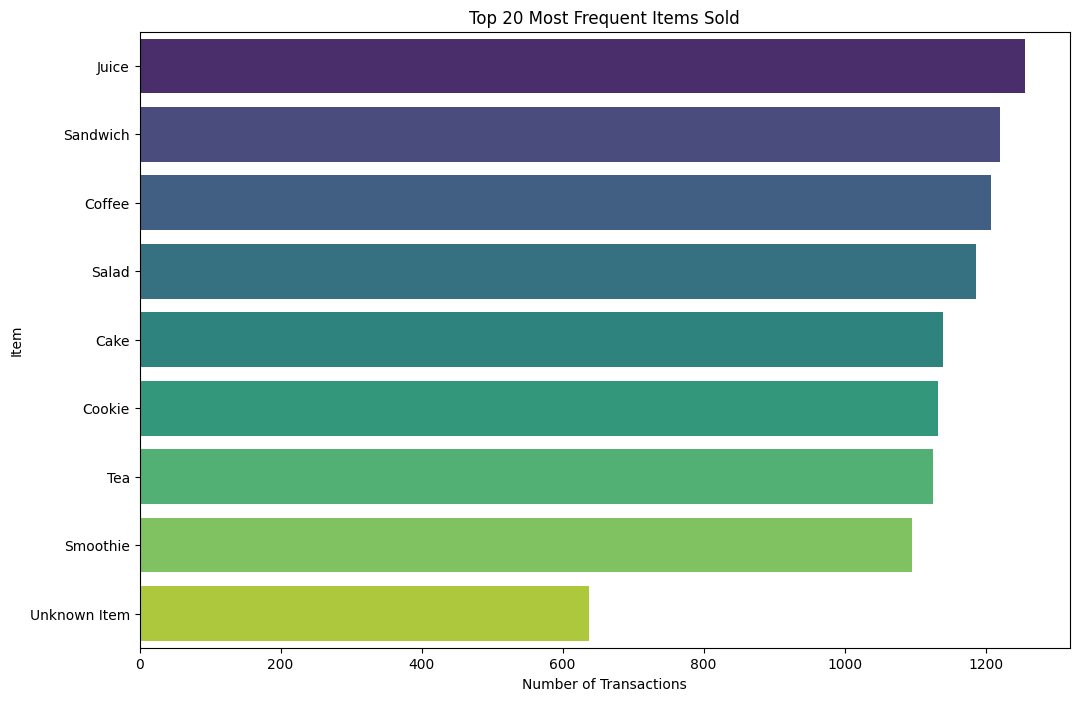


Counts of the top 20 items: 


,Item,Count
0,Juice,1256
1,Sandwich,1220
2,Coffee,1208
3,Salad,1186
4,Cake,1139
5,Cookie,1132
6,Tea,1125
7,Smoothie,1096
8,Unknown Item,638


In [78]:
# 17. EDA graphs and charts

# 17.1 Examining the distribution of items sold. Quick overview of product popularity and 'unknown Item' Imputation

# Get the count of each item.
item_counts = dataset['Item'].value_counts().reset_index()
item_counts.columns = ['Item', 'Count']

# Let us sort by count for better visualisation:
item_counts = item_counts.sort_values(by='Count', ascending=False)

# Plotting it
plt.figure(figsize=(12,8))
sea.barplot(x='Count', y='Item', data=item_counts.head(20), palette='viridis')
plt.title("Top 20 Most Frequent Items Sold")
plt.xlabel('Number of Transactions')
plt.ylabel('Item')
plt.show()

print("\nCounts of the top 20 items: ")
display(item_counts.head(20))


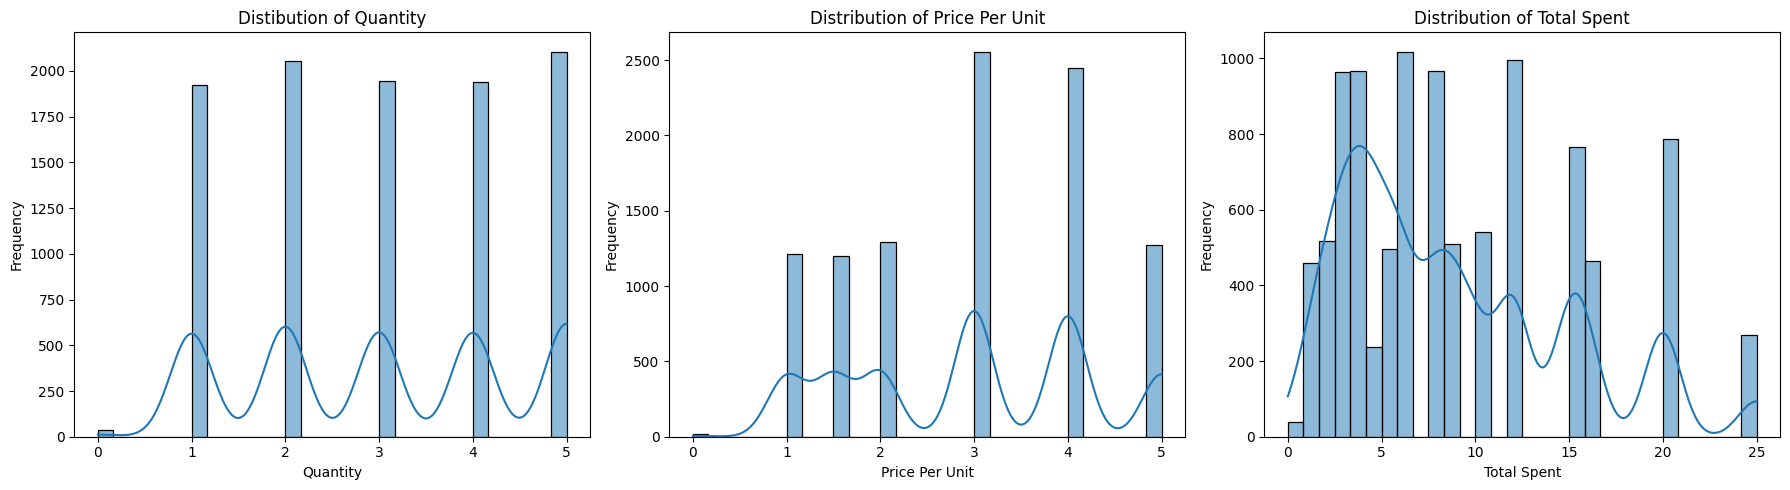

In [79]:
# 17.2: Distribution of Financial Matrices:
# Let us visualise the distribution of 'Q' 'PPU' & 'TS' using Histograms. Understand Spread, values and potential skewness and outliers after imputation.

plt.figure(figsize = (18,5))

# Distribution of Quantity:
plt.subplot(1, 3, 1)
sea.histplot(dataset['Quantity'], bins=30, kde=True)
plt.title("Distibution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

# Distribution of Price Per Unit
plt.subplot(1,3,2)
sea.histplot(dataset['Price Per Unit'], bins=30, kde=True)
plt.title("Distribution of Price Per Unit")
plt.xlabel("Price Per Unit")
plt.ylabel("Frequency")

# Distribution of Total Spent
plt.subplot(1,3,3)
sea.histplot(dataset['Total Spent'], bins=30, kde=True)
plt.title('Distribution of Total Spent')
plt.xlabel("Total Spent")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

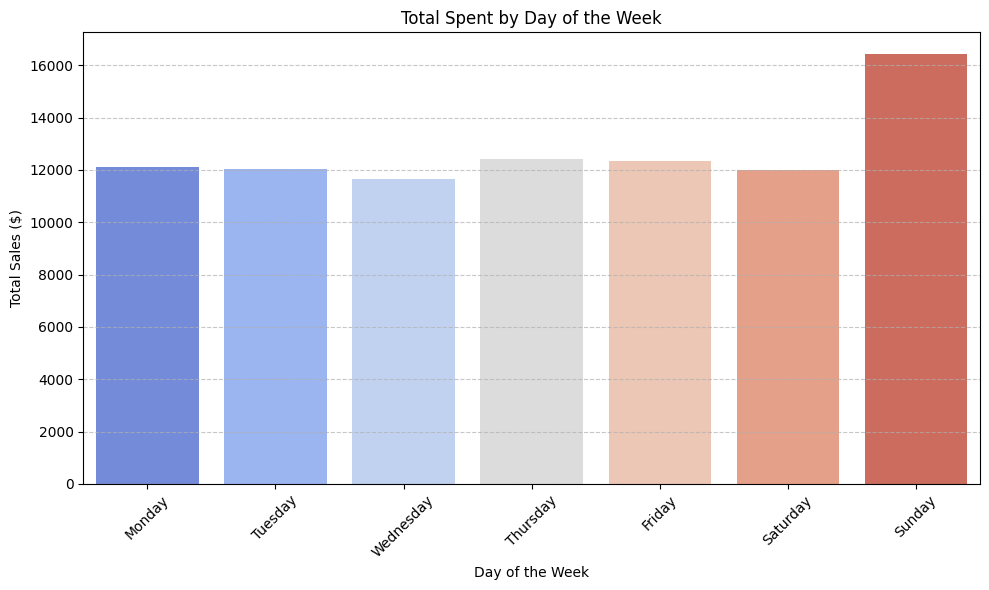


Total Sales by Day of the Week


,Day of Week,Total Spent,Day Name
0,0,12129.5,Monday
1,1,12036.5,Tuesday
2,2,11662.5,Wednesday
3,3,12399.5,Thursday
4,4,12324.0,Friday
5,5,11985.5,Saturday
6,6,16437.0,Sunday


In [80]:
#17.3: Sales trend by Day of Week: how TS varies across days of the week.

sales_by_day_of_week = dataset.groupby('Day of Week')['Total Spent'].sum().reset_index()

# Map numerical day of week to names for better readablitiy:
day_names = ['Monday', 'Tuesday', 'Wednesday','Thursday','Friday','Saturday','Sunday']
sales_by_day_of_week['Day Name'] = sales_by_day_of_week['Day of Week'].map(lambda x: day_names[x])

plt.figure(figsize=(10,6))
sea.barplot(x='Day Name', y='Total Spent', data = sales_by_day_of_week, palette='coolwarm', order=day_names, hue='Day Name', legend=False)
plt.title('Total Spent by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTotal Sales by Day of the Week")
display(sales_by_day_of_week)

In [81]:
dataset.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date', 'Year', 'Month',
       'Day of Week', 'Day_of_Month', 'IsWeekend',
       'Transaction_Date_Missing_Flag'],
      dtype='object')

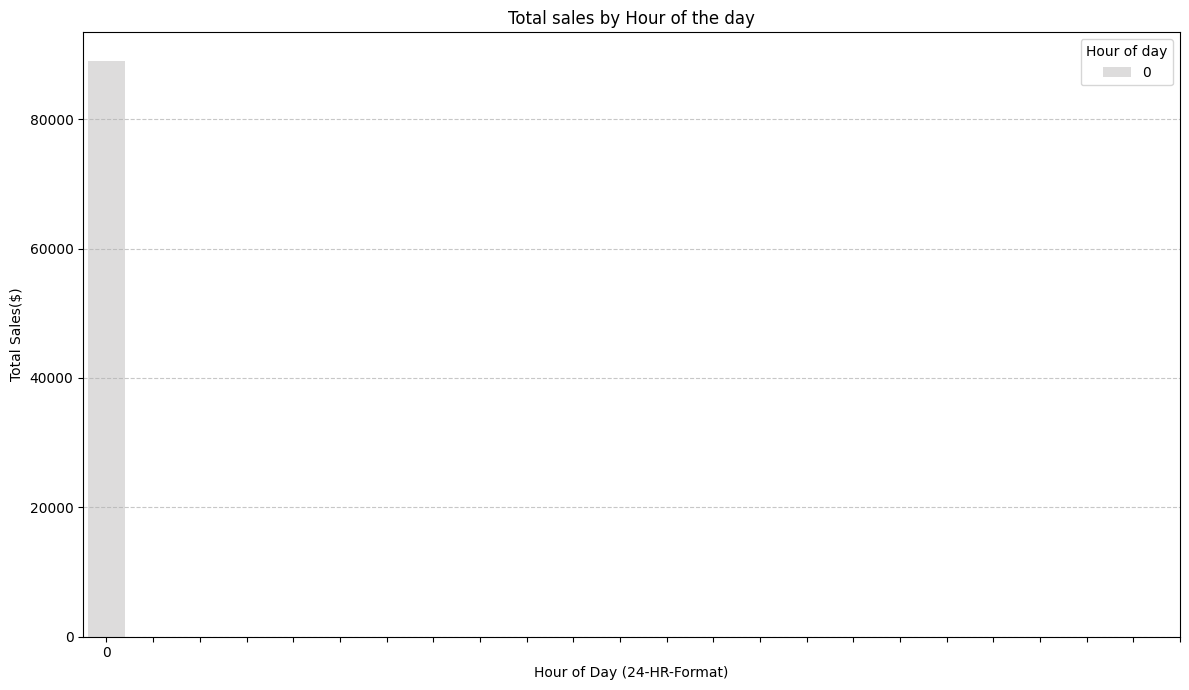

Total sales by Hour of the Day: 


,Hour of day,Total Spent
0,0,88974.5


In [82]:
# 17.4 Sales Trends by Hours
# Understanding sales pattern throughout the day: help optimise staffing, inventory and marketing efforts

# Extract our of day
dataset['Hour of day'] = dataset['Transaction Date'].dt.hour

# Calculating sales per hour
sales_by_hour = dataset.groupby('Hour of day')['Total Spent'].sum().reset_index()

plt.figure(figsize=(12,7))
sea.barplot(x='Hour of day',y='Total Spent',data=sales_by_hour,palette='coolwarm',hue = 'Hour of day')
plt.title('Total sales by Hour of the day')
plt.xlabel('Hour of Day (24-HR-Format)')
plt.ylabel('Total Sales($)')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Total sales by Hour of the Day: ")
display(sales_by_hour)

In [83]:
display(dataset['Transaction Date'].head())

,Transaction Date
0,2023-09-08
1,2023-05-16
2,2023-07-19
3,2023-04-27
4,2023-06-11


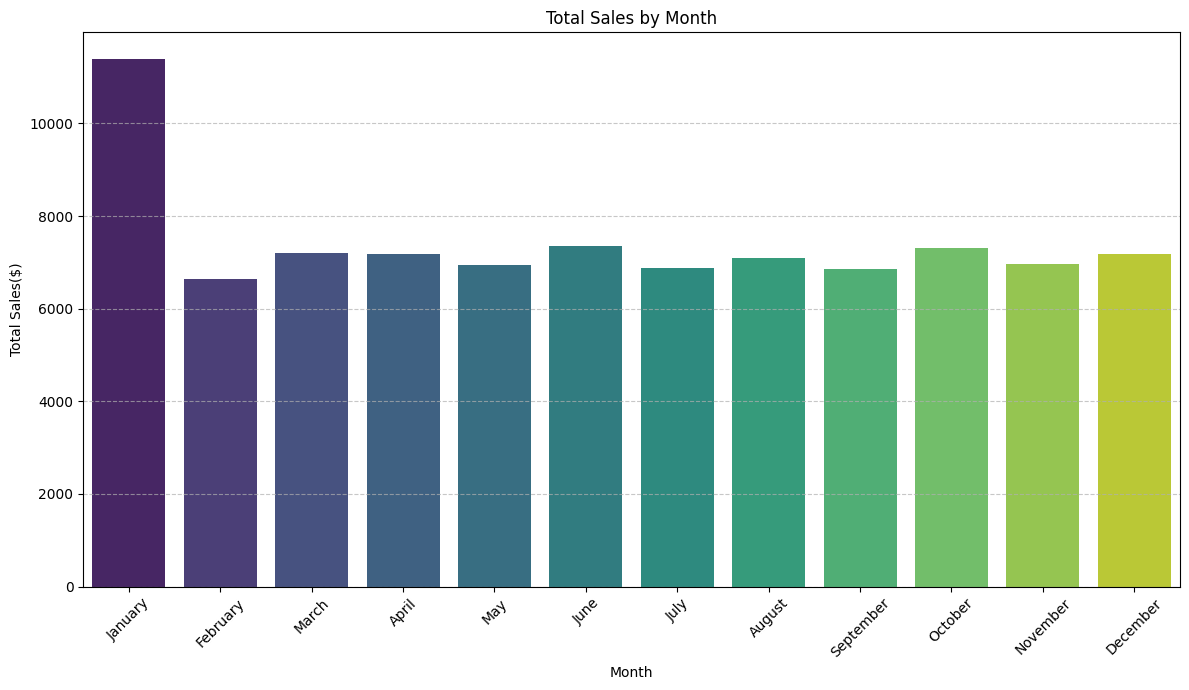

Total Sales By Month


,Month,Total Spent,Month Name
0,1,11396.5,January
1,2,6648.5,February
2,3,7192.0,March
3,4,7179.0,April
4,5,6932.5,May
5,6,7353.0,June
6,7,6876.5,July
7,8,7084.5,August
8,9,6867.0,September
9,10,7307.0,October


In [84]:
# 17.5: Sales trend by Months
sales_by_month = dataset.groupby('Month')['Total Spent'].sum().reset_index()

# Map numerical month to names for better readability
month_names = ['January','February','March','April','May','June','July','August','September','October','November','December']

sales_by_month['Month Name'] = sales_by_month['Month'].map(lambda x: month_names[x-1]) # -1 because months are 1-indexed

plt.figure(figsize=(12,7))
sea.barplot(x='Month Name', y='Total Spent', data= sales_by_month, palette='viridis', order=month_names, hue='Month Name')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel("Total Sales($)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Total Sales By Month')
display(sales_by_month)


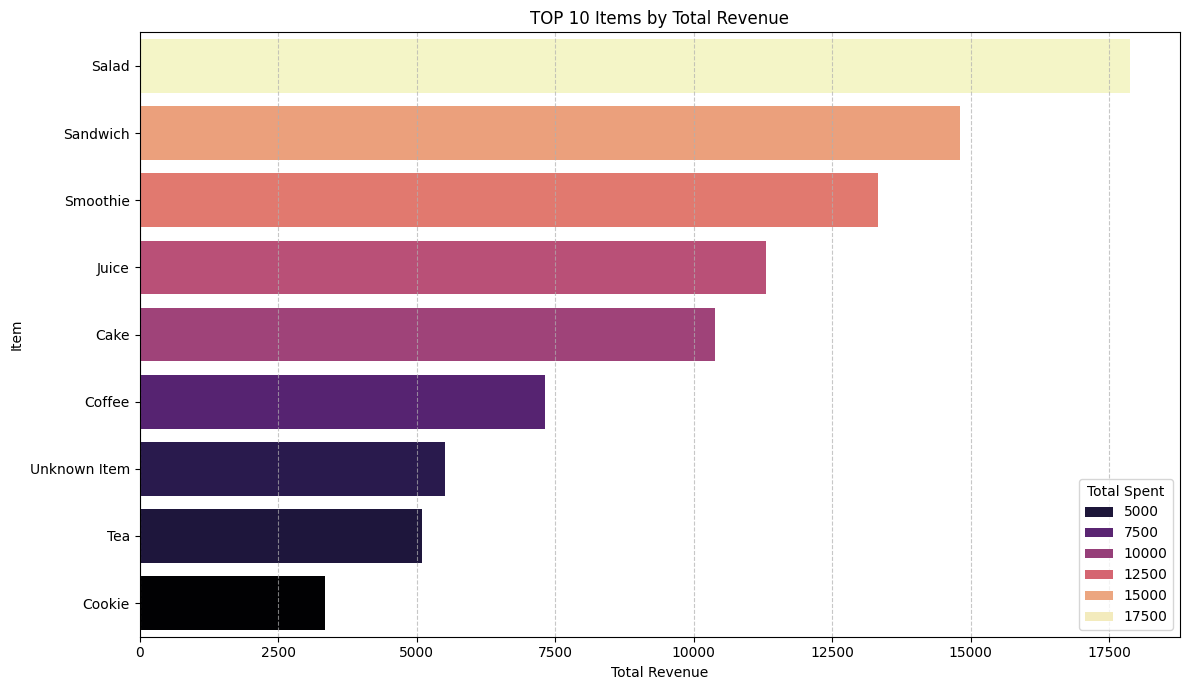


Top 10 items by total revenue


,Item,Total Spent
4,Salad,17885.0
5,Sandwich,14804.0
6,Smoothie,13320.0
3,Juice,11301.0
0,Cake,10386.0
1,Coffee,7322.0
8,Unknown Item,5513.5
7,Tea,5100.0
2,Cookie,3343.0


In [85]:
# 17.6: Sales Revenue by Item
# Which item is most profitable?
revenue_by_item = dataset.groupby('Item')['Total Spent'].sum().reset_index()

# Sort Total Revenue by Item:
revenue_by_item = revenue_by_item.sort_values(by='Total Spent', ascending=False)

plt.figure(figsize=(12,7))
sea.barplot(x='Total Spent', y='Item', data = revenue_by_item, palette='magma',hue='Total Spent')
plt.title("TOP 10 Items by Total Revenue")
plt.xlabel('Total Revenue')
plt.ylabel('Item')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("\nTop 10 items by total revenue")
display(revenue_by_item)

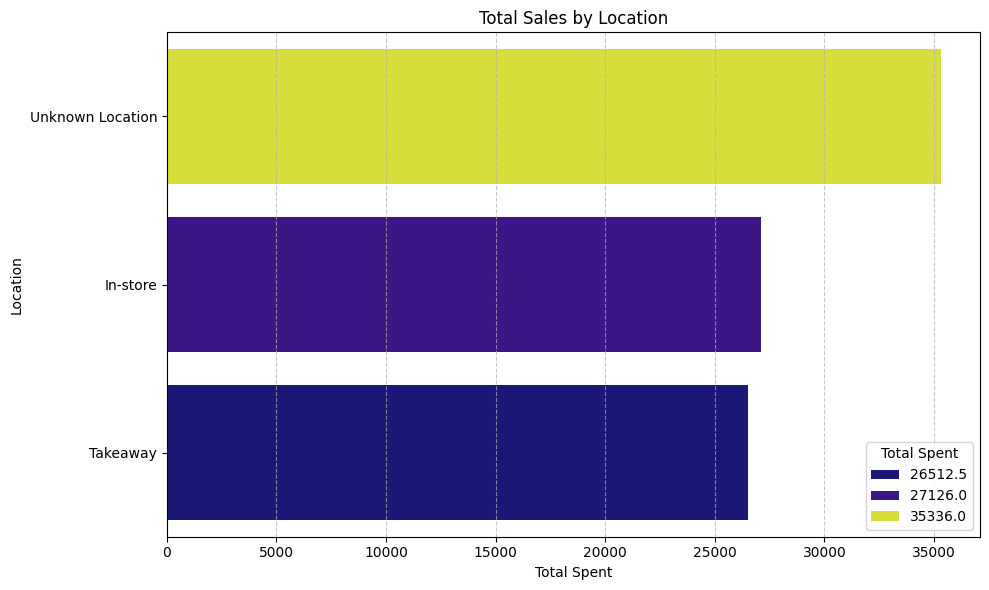

Total Sales by Location


,Location,Total Spent
2,Unknown Location,35336.0
0,In-store,27126.0
1,Takeaway,26512.5


In [86]:
# 17.7: Sales trend by Location

sales_by_location = dataset.groupby('Location')['Total Spent'].sum().reset_index()

# Sort by total spent
sales_by_location = sales_by_location.sort_values(by='Total Spent', ascending=False)

plt.figure(figsize=(10,6))
sea.barplot(x='Total Spent', y='Location', data = sales_by_location, palette='plasma', hue='Total Spent')
plt.title("Total Sales by Location")
plt.xlabel('Total Spent')
plt.ylabel('Location')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Total Sales by Location")
display(sales_by_location)

/tmp/ipykernel_3426/3345576994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(x='Total Spent', y='Payment Method', data=sales_by_payment_method, palette='rocket')


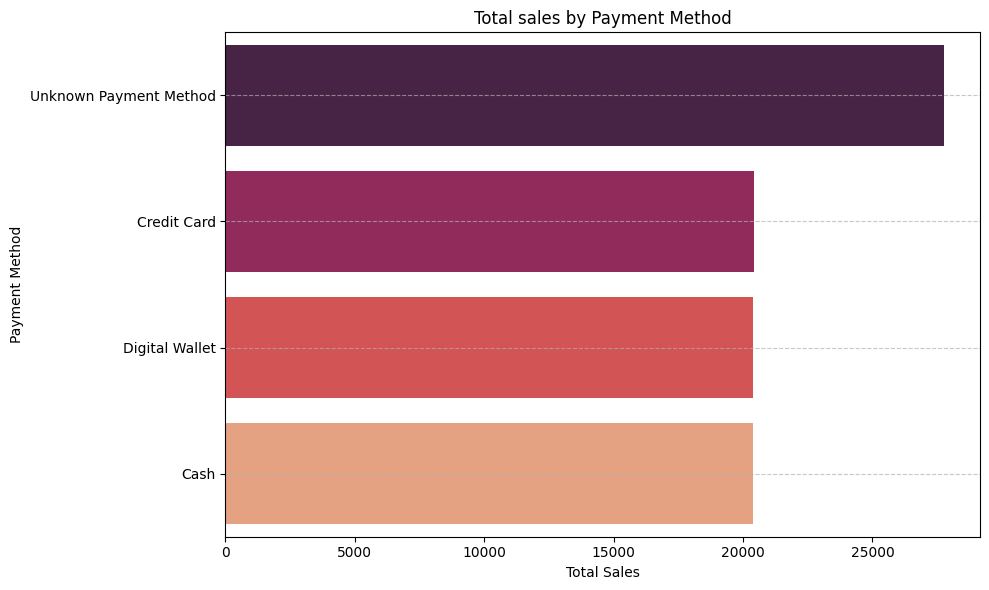


Total Sales By Payment Method


,Payment Method,Total Spent
3,Unknown Payment Method,27767.5
1,Credit Card,20437.5
2,Digital Wallet,20393.0
0,Cash,20376.5


In [87]:
# 17.8: Sales trends by Payment Method:

# Let us analyse total sales by each Payment Method
sales_by_payment_method = dataset.groupby('Payment Method')['Total Spent'].sum().reset_index()

#Sort by Total Spent
sales_by_payment_method = sales_by_payment_method.sort_values(by='Total Spent', ascending= False)

plt.figure(figsize=(10,6))
sea.barplot(x='Total Spent', y='Payment Method', data=sales_by_payment_method, palette='rocket')
plt.title('Total sales by Payment Method')
plt.xlabel('Total Sales')
plt.ylabel('Payment Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTotal Sales By Payment Method")
display(sales_by_payment_method)


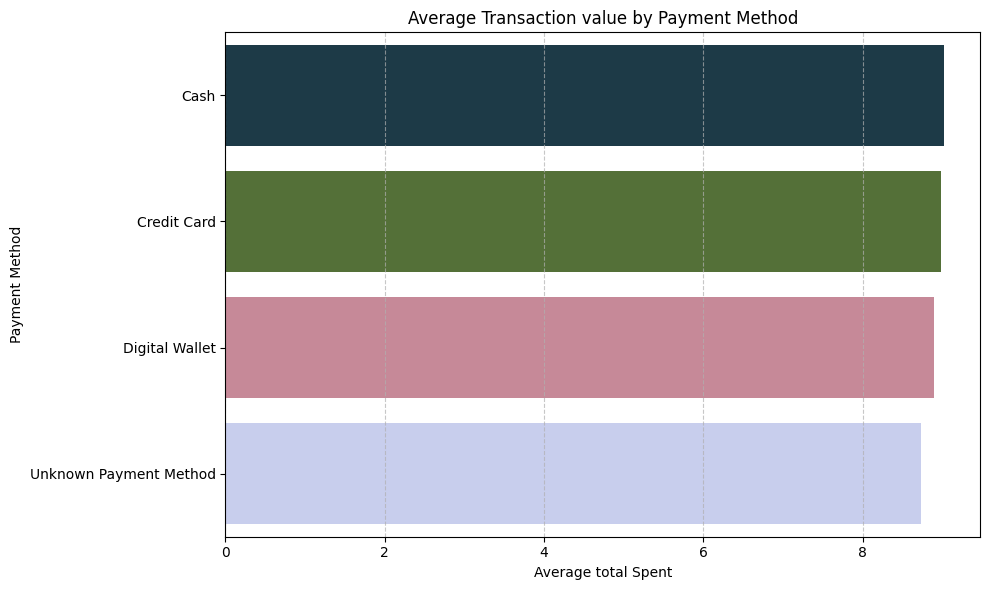


 Average Transaction Value by Payment Method


,Payment Method,Total Spent
0,Cash,9.024136
1,Credit Card,8.991421
2,Digital Wallet,8.901353
3,Unknown Payment Method,8.737413


In [88]:
# 17.9:
average_spent_by_paymentm = dataset.groupby('Payment Method')['Total Spent'].mean().reset_index()

# Sort by AVG spent
average_spent_by_paymentm = average_spent_by_paymentm.sort_values(by='Total Spent', ascending=False)

plt.figure(figsize=(10,6))
sea.barplot(x='Total Spent', y='Payment Method', data=average_spent_by_paymentm, palette='cubehelix', hue='Payment Method', legend=False)
plt.title('Average Transaction value by Payment Method')
plt.xlabel('Average total Spent')
plt.ylabel('Payment Method')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n Average Transaction Value by Payment Method")
display(average_spent_by_paymentm)

Top 5 Items by Total Revenue per Location:


/tmp/ipykernel_3426/342343938.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_items_per_location = revenue_by_item_location.groupby('Location').apply(get_top_n_items).reset_index(drop=True)


,Location,Item,Total Spent
0,In-store,Salad,5830.0
1,In-store,Sandwich,4772.0
2,In-store,Smoothie,3812.0
3,In-store,Juice,3576.0
4,In-store,Cake,2958.0
5,Takeaway,Salad,5250.0
6,Takeaway,Sandwich,4588.0
7,Takeaway,Smoothie,3680.0
8,Takeaway,Juice,3249.0
9,Takeaway,Cake,3141.0


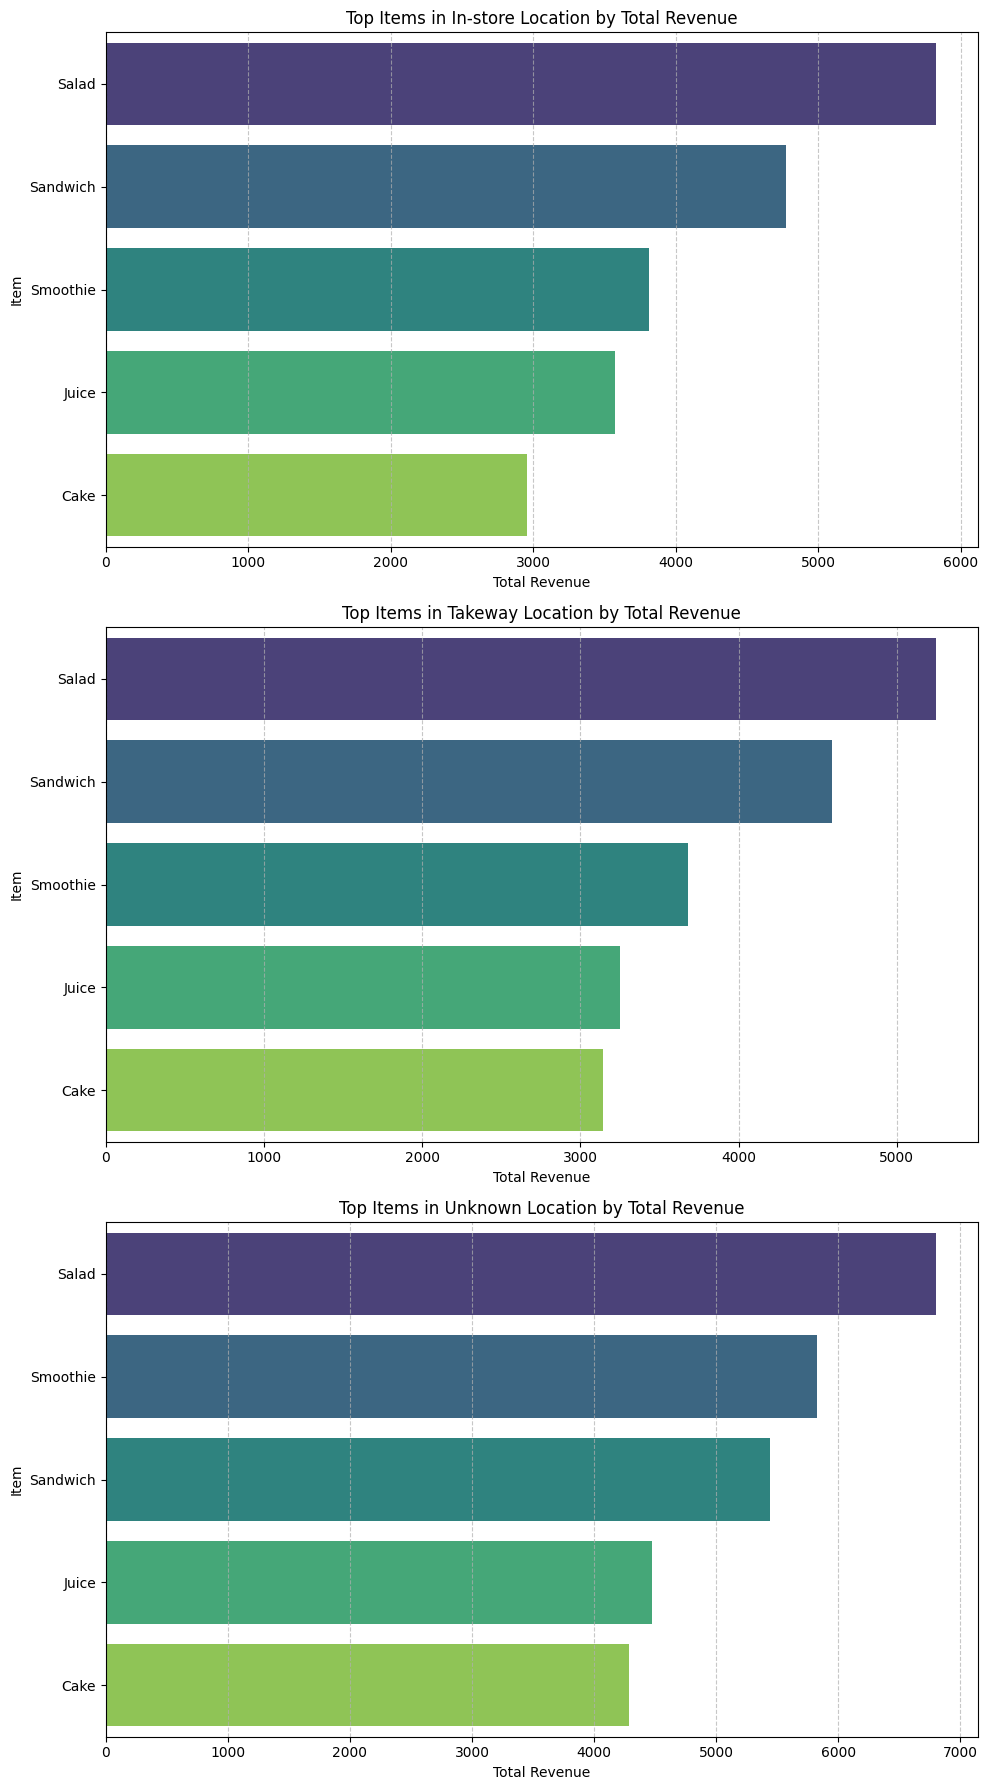

In [89]:
# 17.10: Top Selling Item By Location
revenue_by_item_location = dataset.groupby(['Location', 'Item'])['Total Spent'].sum().reset_index()

# find top N items for each location
def get_top_n_items(df, n=5):
  return df.sort_values(by='Total Spent',ascending = False).head(n)

top_items_per_location = revenue_by_item_location.groupby('Location').apply(get_top_n_items).reset_index(drop=True)

print('Top 5 Items by Total Revenue per Location:')
display(top_items_per_location)

# Let us visualise top items:

plt.figure(figsize= (10, 18)) # Adjusted figure size for vertical layout

plt.subplot(3,1,1) # Changed to 3 rows, 1 column
sea.barplot(x='Total Spent', y='Item', data=top_items_per_location[top_items_per_location['Location']=='In-store'], palette='viridis',hue='Item', legend=False) # Corrected 'In-Store' to 'In-store'
plt.title('Top Items in In-store Location by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Item')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplot(3,1,2) # Changed to 3 rows, 1 column
sea.barplot(x='Total Spent', y='Item', data=top_items_per_location[top_items_per_location['Location']=='Takeaway'], palette='viridis',hue='Item', legend=False)
plt.title('Top Items in Takeway Location by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Item')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplot(3,1,3) # Changed to 3 rows, 1 column
sea.barplot(x='Total Spent', y='Item', data=top_items_per_location[top_items_per_location['Location']=='Unknown Location'], palette='viridis',hue='Item', legend=False)
plt.title('Top Items in Unknown Location by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Item')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

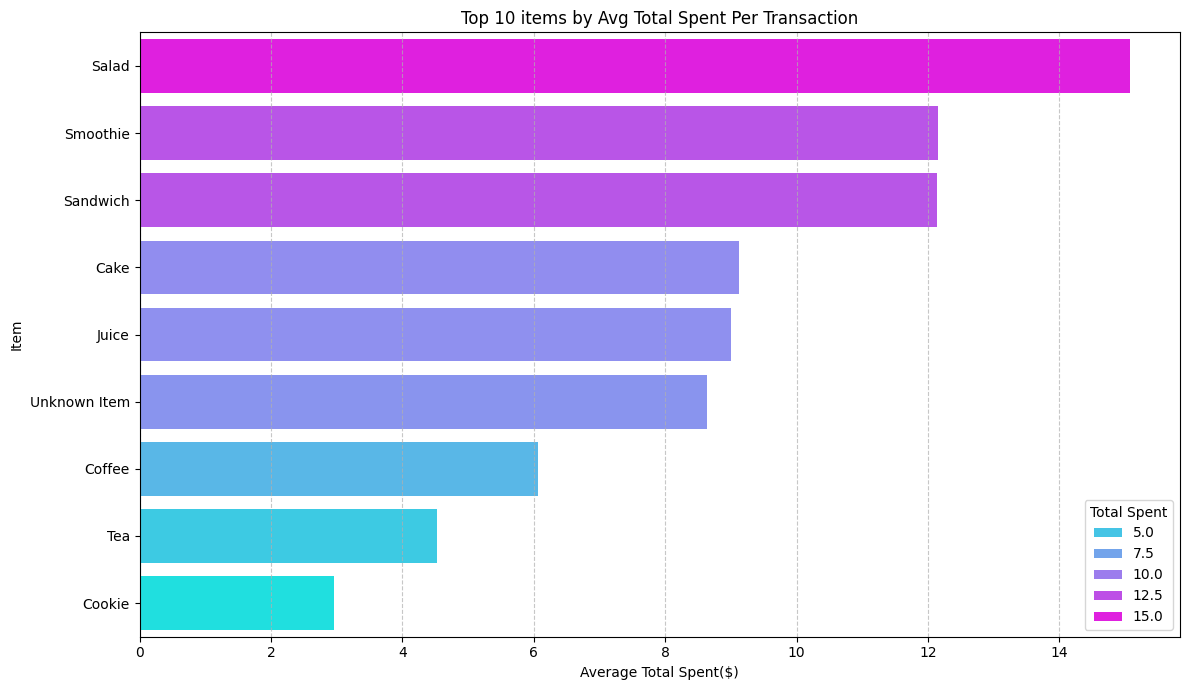


Top 10 Items by Avg Total Spent per Transaction


,Item,Total Spent
4,Salad,15.080101
6,Smoothie,12.153285
5,Sandwich,12.134426
0,Cake,9.118525
3,Juice,8.997611
8,Unknown Item,8.641850
1,Coffee,6.061258
7,Tea,4.533333
2,Cookie,2.953180


In [90]:
# 17.11: Average Total Spent Per Item
# This means that for each item, what is the average Total Spent across all transactions that include it.
# We are using the mean of TS grouped by Item

average_spent_per_item = dataset.groupby('Item')['Total Spent'].mean().reset_index()

# Sort it by TS
average_spent_per_item = average_spent_per_item.sort_values(by='Total Spent', ascending=False)

plt.figure(figsize=(12,7))
sea.barplot(x='Total Spent', y= 'Item', data=average_spent_per_item.head(10),palette='cool',hue='Total Spent')
plt.title('Top 10 items by Avg Total Spent Per Transaction')
plt.xlabel('Average Total Spent($)')
plt.ylabel('Item')
plt.grid(axis='x', linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 10 Items by Avg Total Spent per Transaction")
display(average_spent_per_item)

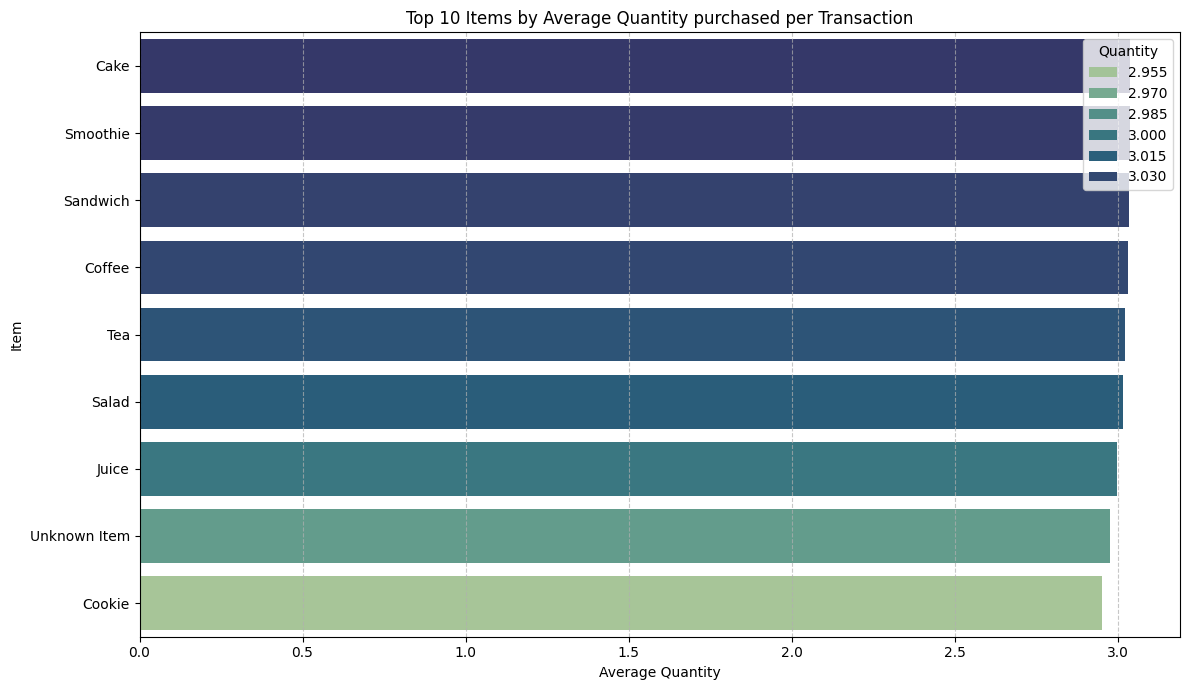


Top 10 Items by Average Quantity Purchased per Transaction


,Item,Quantity
0,Cake,3.039508
6,Smoothie,3.038321
5,Sandwich,3.033607
1,Coffee,3.030629
7,Tea,3.022222
4,Salad,3.016020
3,Juice,2.999204
8,Unknown Item,2.978056
2,Cookie,2.953180


In [91]:
# 17.12: Average Quantity purchased Per item
average_quantity_per_item = dataset.groupby('Item')['Quantity'].mean().reset_index()

average_quantity_per_item = average_quantity_per_item.sort_values(by='Quantity', ascending=False)

plt.figure(figsize=(12,7))
sea.barplot(x='Quantity', y='Item', data=average_quantity_per_item.head(10), palette='crest', hue='Quantity')
plt.title('Top 10 Items by Average Quantity purchased per Transaction')
plt.xlabel('Average Quantity')
plt.ylabel('Item')
plt.grid(axis='x',linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 10 Items by Average Quantity Purchased per Transaction")
display(average_quantity_per_item)

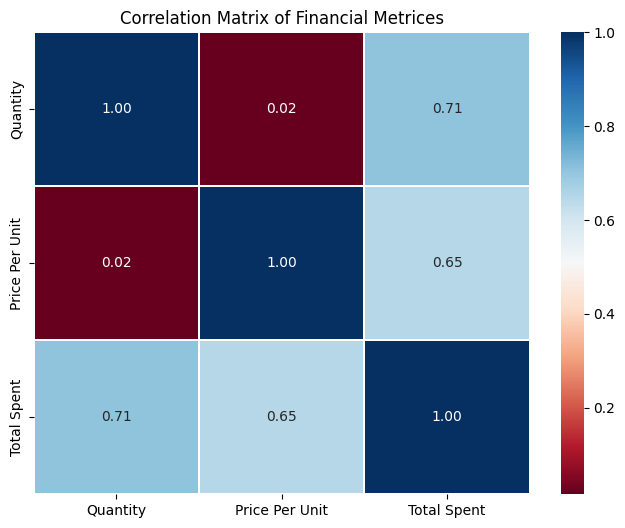


Correlation Matrix of Quantity, Price per Unit, and Total Spent:


,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.015580,0.707073
Price Per Unit,0.015580,1.000000,0.646563
Total Spent,0.707073,0.646563,1.000000


In [92]:
# 17.13: Let us find the correlation analysis of Financial Metrices.
financial_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

correlation_matrix = dataset[financial_cols].corr()

plt.figure(figsize=(8,6))
sea.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidth=.25)
plt.title("Correlation Matrix of Financial Metrices")
plt.show()

print("\nCorrelation Matrix of Quantity, Price per Unit, and Total Spent:")
display(correlation_matrix)

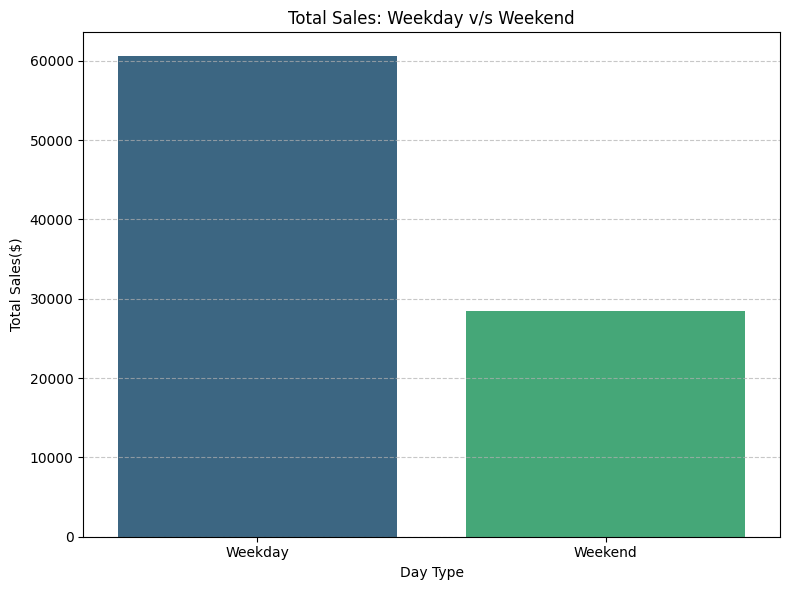


Total Sales by Day Type


,IsWeekend,Total Spent,Day_Type
0,0,60552.0,Weekday
1,1,28422.5,Weekend


In [93]:
# 17.14: Sales Trends on Weekdays v/s Weekends
sales_by_weekend = dataset.groupby('IsWeekend')['Total Spent'].sum().reset_index()

sales_by_weekend['Day_Type'] = sales_by_weekend['IsWeekend'].map({0:'Weekday', 1:'Weekend'})
plt.figure(figsize=(8,6))
sea.barplot(x='Day_Type', y='Total Spent', data=sales_by_weekend,palette='viridis', hue='Day_Type')
plt.title('Total Sales: Weekday v/s Weekend')
plt.xlabel('Day Type')
plt.ylabel('Total Sales($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTotal Sales by Day Type")
display(sales_by_weekend)

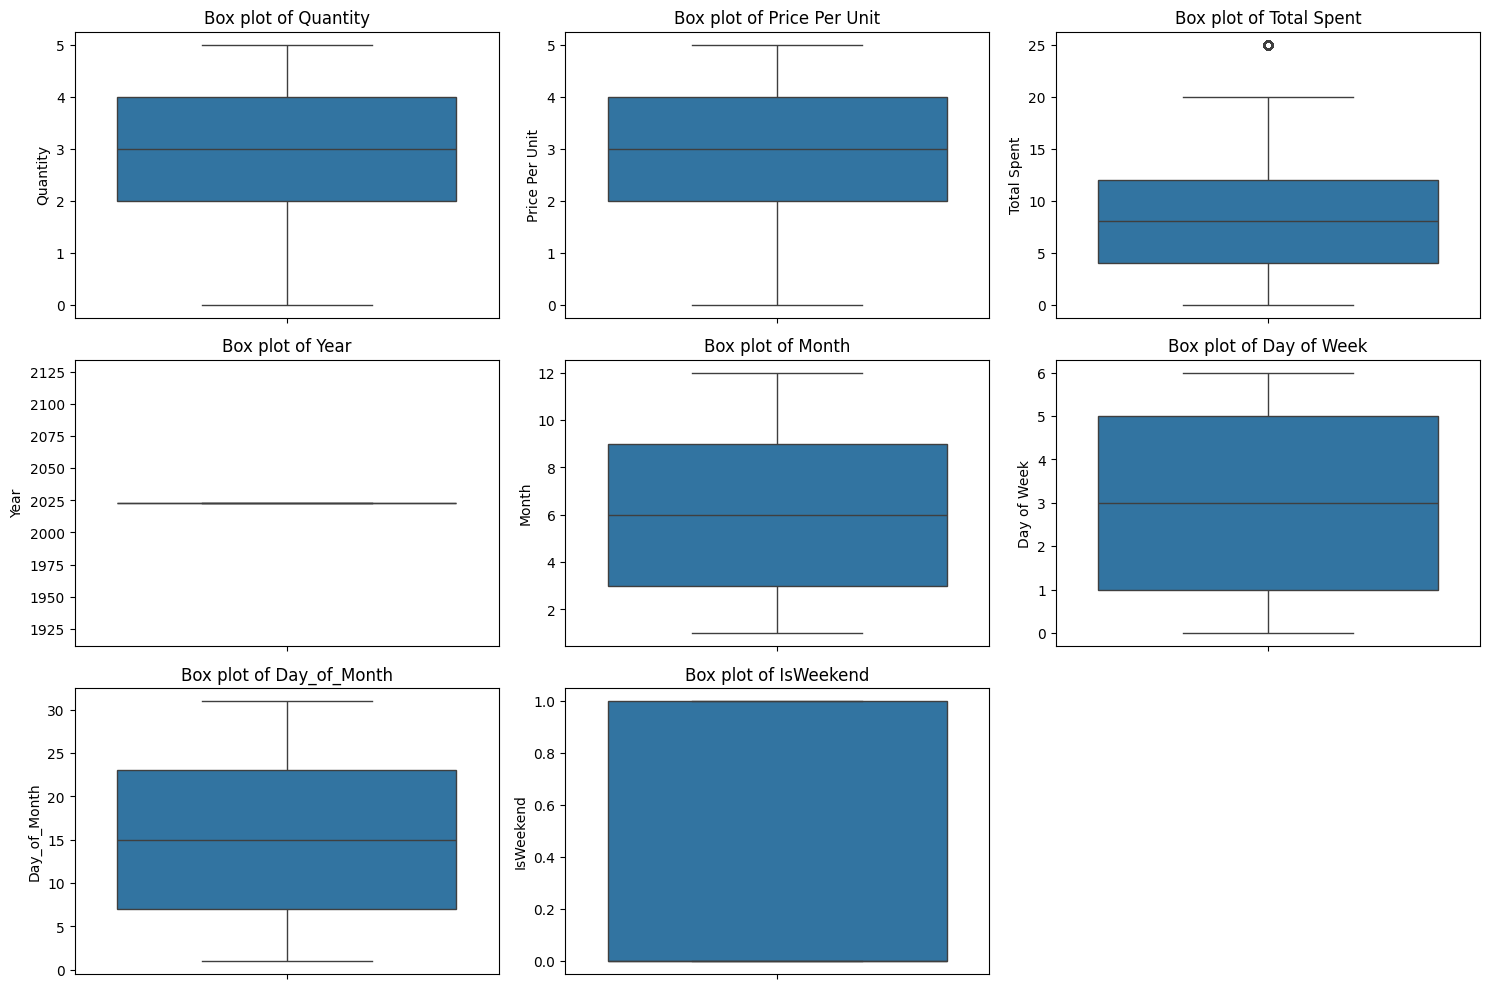

In [94]:
# 17.15: Outlier Analysis with Box Plot
numerical_features

plt.figure(figsize=(15,10))
for i, feature in enumerate(numerical_features):
  plt.subplot(3,3,i+1)
  sea.boxplot(y=dataset[feature])
  plt.title(f"Box plot of {feature}")
  plt.ylabel(feature)

plt.tight_layout()
plt.show()


### Key Insights from Our Exploratory Data Analysis (EDA)

Our journey through the data has revealed some interesting patterns and important observations about our cafe's sales. Here’s a quick recap of what we've learned:

*   **Popularity & Profit**: Not all popular items are the biggest money-makers! While 'Juice', 'Sandwich', and 'Coffee' fly off the shelves most often, 'Salad', 'Sandwich', and 'Smoothie' bring in the most cash. This suggests some items might be niche but carry a higher price tag or are bought in larger quantities.

*   **Spending Habits**: Most transactions involve smaller quantities, lower prices, and less total spending. We see a few transactions with much higher values, which stand out as interesting outliers for further investigation.

*   **Weekly Rhythm**: Sundays are our busiest sales days, closely followed by Thursdays and Fridays. It seems people are either enjoying a weekend treat or gearing up for the end of the work week. While individual weekdays might not match Sunday, the overall weekday period generates more sales than the combined weekend.

*   **Daily Flow**: There's a clear midday rush, typically between noon and early afternoon. This is a classic peak for cafes, perfect for planning staffing and promotions.

*   **Monthly Consistency**: Sales tend to be quite steady throughout the year, with a slight bump around the beginning and end of the year (January, October, November, December).

*   **Location, Location, Location**: A significant portion of sales comes from 'Unknown Location'. This could be a data capture issue, but among the identified locations, 'In-store' and 'Takeaway' perform similarly. This 'Unknown Location' requires further investigation to understand its nature.

*   **Payment Preferences**: 'Unknown Payment Method' leads in total sales, highlighting another area where data collection could improve. Among known methods, Credit Cards and Digital Wallets are strong contenders for total sales, but interestingly, cash transactions have a slightly higher *average* value.

*   **Relationships between Sales Metrics**: As expected, the quantity of items sold and their price per unit are both directly linked to the total amount spent. The more items sold or the higher their price, the more revenue generated. However, quantity and price per unit don't strongly influence each other independently.

These insights paint a clearer picture of our cafe's operations, customer behavior, and sales performance, which will be invaluable as we move forward to predict future trends with our machine learning model!